# Example: Updating the Single Index Model Online with EWLS
In this example, we let the single index model (SIM) parameters of the thirteen course firms move as data arrive. We first ask whether the frozen archive values are even stable inside the training period, by re-estimating beta on rolling one-year windows with the L6a confidence bands. We then run exponentially weighted least squares (EWLS) on the training growth rates, choose the half-life by a walk-forward comparison that never touches 2025, declare it, and only then run the recursion through 2025 from the archive prior, comparing the online intercept and beta paths with the frozen values and reading what the update does to the preference thresholds, the basket, and the SIM covariance matrix.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Read rolling estimates against a scale:__ Estimate the SIM beta of a firm on rolling one-year windows, draw the classical pointwise band around each estimate, and read excursions of many band-widths lasting years as a reason to test an updating rule, while saying what such bands do not establish.
> * __Run and calibrate the EWLS recursion:__ Seed the recursion with a prior, update it one observation at a time, choose the half-life by a walk-forward comparison of conditional one-step-ahead prediction errors inside the training period, and state the choice before the test year is opened.
> * __Read what an online update changes:__ Compare the online and frozen parameter paths through 2025 and translate the difference into the preference thresholds, the number of days each firm is preferred, and the distance between the online and frozen SIM covariance matrices.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`
Precompiling packages...
   4013.3 ms  ✓ VLQuantitativeFinancePackage
  1 dependency successfully precompiled in 5 seconds. 528 already precompiled.
  35 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, IJulia, InteractiveUtils, JLLWrappers, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, PrecompileTools, Preferences, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, ZMQ, ZeroMQ_jll, Zlib_jll, libsodium_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 344 dependents of these packages may trigger further precompilation to work with the unexpected versions.


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [Distributions.jl](https://juliastats.org/Distributions.jl/stable/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, and the half-life we choose below is chosen inside it. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), which the recursion is replayed through only after the half-life is declared.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive that the L6a estimation example saved, `SIMs-SP500-01-03-14-to-12-31-24.jld2`, [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/). The archive holds, for every security fitted against SPY on the training data, the estimated intercept $\hat{\alpha}_{i}$ and beta $\hat{\beta}_{i}$ (fields `alpha`, `beta`), their classical standard errors (fields `alpha_SE`, `beta_SE`), the residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (field `training_variance`, units: inverse years squared), and the coefficient of determination; and, once for the whole archive, the training-period sample mean $g^{\prime}_{M}$ and sample variance $s^{2}_{g,M}$ of the market growth rate (keys `market_mean` and `market_variance`). One fact about the archive matters today: its growth rates were built from __volume-weighted average prices__ (VWAP), while everything we compute below uses __close__ prices, the prices the L7a engine trades at. We check the variance convention, store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the two market moments in the `g_market_mean::Float64` and `σ²_market::Float64` variables:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10]); growth definition: $(archive["growth_definition"])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31; growth definition: g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted


### Constants
Finally, let's specify some constants that we will use in our analysis. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
window = 252; # rolling-window length for the rolling OLS betas (trading days, about one year)
half_lives = [21.0, 63.0, 126.0, 252.0, Inf]; # candidate EWLS half-lives t½ (trading days); Inf is the recursion with no forgetting (expanding-window OLS)
N₀ = 63.0; # weight of the archive prior when the recursion restarts on 2025 (pseudo-observations, one trading quarter)
warmup_days = 252; # the walk-forward half-life search seeds the recursion with an OLS fit on the first 252 training growth rates (January 6, 2014 to January 5, 2015) and updates from there
first_evaluation_date = Date(2020, 1, 1); # the walk-forward search scores one-step-ahead errors from this date to the end of 2024
L_short = 21; # short exponential moving average window (trading days), as in L7a
L_long = 63; # long exponential moving average window (trading days), as in L7a
L_growth = 10; # window of the exponential moving average of the daily market growth rate (trading days), as in L7a

___

## Task 1: Firms, Growth Rates, and the Archive Parameters
We use the same $|\mathcal{P}| = 13$ firms as the L5b, L6b, and L7a examples, stored in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b, L6b, and L7a

The recursion consumes daily growth rates in annualized units, $g_{i,t} = \ln\left(S_{i}(t)/S_{i}(t-1)\right)/\Delta{t}$ for asset $i$ and $g_{M,t}$ for the market index SPY (units: inverse years), computed from __close__ prices. We build the training growth-rate matrix (rows are days from January 6, 2014 to December 31, 2024, columns are the firms in the order of `my_list_of_tickers`), the training market growth-rate vector, and the same two objects for 2025, checking that the dates are aligned; because the first 2025 growth rate is the growth into the first trading day of 2025 from the last close of 2024, we build the 2025 series from the joined price series. We also pull the archive parameters $\hat{\alpha}_{i}$, $\hat{\beta}_{i}$, and $s^{2}_{g,\varepsilon,i}$ for our firms. We store the results in the `G_train::Array{Float64,2}`, `g_M_train::Array{Float64,1}`, `dates_train::Array{Date,1}`, `G_2025::Array{Float64,2}`, `g_M_2025::Array{Float64,1}`, `α̂::Array{Float64,1}`, `β̂::Array{Float64,1}`, and `s²_ε::Array{Float64,1}` variables:

In [7]:
G_train, g_M_train, dates_train, G_2025, g_M_2025, α̂, β̂, s²_ε = let
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end

    # close prices, training then 2025 -
    S_train = hcat([dataset[ticker][:, :close] for ticker ∈ my_list_of_tickers]...); # N_train × |𝒫| (USD/share)
    spy_train = dataset["SPY"][:, :close];
    S_2025 = hcat([dataset_2025[ticker][:, :close] for ticker ∈ my_list_of_tickers]...);
    spy_2025 = dataset_2025["SPY"][:, :close];

    # annualized daily growth rates from close prices (units: 1/years) -
    G_train = log.(S_train[2:end, :] ./ S_train[1:end-1, :]) ./ Δt;
    g_M_train = log.(spy_train[2:end] ./ spy_train[1:end-1]) ./ Δt;
    dates_train = Date.(dataset["AAPL"].timestamp[2:end]); # date of the close each growth rate runs into
    S_joined = vcat(S_train[end:end, :], S_2025); spy_joined = vcat(spy_train[end], spy_2025); # last 2024 close, then 2025
    G_2025 = log.(S_joined[2:end, :] ./ S_joined[1:end-1, :]) ./ Δt; # growth into each 2025 close, starting from the last close of 2024
    g_M_2025 = log.(spy_joined[2:end] ./ spy_joined[1:end-1]) ./ Δt;

    # archive parameters for our firms -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)
    @assert all(β̂ .> 0) # the L7a preference model raises β to a real power

    println("training: $(size(G_train, 1)) daily growth rates ($(dates_train[1]) to $(dates_train[end])); 2025: $(size(G_2025, 1)) daily growth rates; close-based market growth: mean $(round(mean(g_M_train), digits=3)) 1/yr, variance $(round(var(g_M_train), digits=2)) 1/yr² (archive, from VWAP: $(round(g_market_mean, digits=3)), $(round(σ²_market, digits=2)))")
    (G_train, g_M_train, dates_train, G_2025, g_M_2025, α̂, β̂, s²_ε); # return
end;

training: 2766 daily growth rates (2014-01-06 to 2024-12-31); 2025: 250 daily growth rates; close-based market growth: mean 0.106 1/yr, variance 7.51 1/yr² (archive, from VWAP: 0.106, 4.6)


The close-based market growth rate has the same mean as the archive's VWAP-based one but a larger variance: averaging prices over the trading day smooths the series (L6a). Before we let anything move, we check how much the choice of price series alone shifts the frozen parameters, by refitting the full-sample ordinary least squares (OLS) regression of L6a on the close-based training growth rates and setting it next to the archive. Let's fit and tabulate [using the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/):

In [8]:
let
    N_train = size(G_train, 1);
    X̂ = hcat(ones(N_train), g_M_train); # design matrix: a column of ones and the market growth rates (L6a)
    df = DataFrame(ticker = String[], α_archive = Float64[], β_archive = Float64[], SE_β = Float64[], α_close = Float64[], β_close = Float64[]);
    for (k, ticker) ∈ enumerate(my_list_of_tickers)
        θ = X̂ \ G_train[:, k]; # least-squares solve, no explicit inverse
        push!(df, (ticker = ticker, α_archive = round(α̂[k], digits=3), β_archive = round(β̂[k], digits=3), SE_β = round(sim_parameters[ticker].beta_SE, digits=3), α_close = round(θ[1], digits=3), β_close = round(θ[2], digits=3)));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- ----------- ----------- --------- --------- ---------
  ticker   α_archive   β_archive      SE_β   α_close   β_close 
  String     Float64     Float64   Float64   Float64   Float64 
 -------- ----------- ----------- --------- --------- ---------
    AAPL       0.106       1.195     0.024     0.108     1.186
    MSFT         0.1       1.152     0.021     0.094     1.206
    INTC      -0.148       1.184     0.035    -0.156     1.254
      MU      -0.053       1.695     0.047    -0.041      1.58
     AMD       0.127       1.739     0.058     0.137     1.636
    NVDA       0.347       1.749     0.043     0.349     1.719
      GS      -0.033        1.31     0.024     -0.02     1.192
     BAC      -0.055       1.359     0.028    -0.042     1.238
     WFC      -0.091       1.238     0.029    -0.082     1.152
       C      -0.133       1.501     0.028    -0.116     1.329
       F      -0.193       1.434     0.036    -0.165     1.171
      GM      -0.129        1.47     0.036    -0.10

The intercepts agree to a few hundredths per year, and most betas to within a few standard errors; the largest gaps (F, GM, C) are a fifth of a unit of beta, which is what a smoother market series does to a slope. Two arms are compared throughout L7b: the __frozen__ arm uses the archive parameters as they are, VWAP and all, because that is what L7a's engine used; the __online__ arm starts from the archive parameters as its prior and updates on close-based growth rates, the series the engine trades on.
___

## Task 2: Are the Frozen Betas Even Stable? Rolling Windows with Bands
The archive gives one beta per firm for eleven years, a single pooled slope over the whole sample. Before updating anything, we ask whether that number describes the decade or masks time variation inside it. We refit the L6a regression on a rolling window of one trading year (`window` days) ending on each day $t$, which gives a rolling estimate $\hat{\beta}_{i}(t)$ together with its classical standard error $\text{SE}(\hat{\beta}_{i}(t)) = \sqrt{s^{2}_{g,\varepsilon,i}(t)\left[(\hat{\mathbf{X}}_{t}^{\top}\hat{\mathbf{X}}_{t})^{-1}\right]_{22}}$ from that window's design matrix $\hat{\mathbf{X}}_{t}$ and residual variance $s^{2}_{g,\varepsilon,i}(t)$ (L6a: the residual variance times the second diagonal element of the inverse Gram matrix), and the band $\hat{\beta}_{i}(t)\pm 1.96\,\text{SE}$. The band gives the motion a scale, and it needs two honest labels. It is a __descriptive, classical, pointwise__ interval: it assumes independent, homoskedastic residuals (which daily growth rates violate, L6a), each window's interval is pointwise, and successive windows overlap in 251 of 252 days, so the intervals are neither independent nor a joint band; a rolling estimate wanders inside such bands even when the true parameter is constant, and it leaves them now and then by chance. What the bands cannot be read as, an excursion of a few band-widths, they can be read as when the excursion is many band-widths wide and lasts for years: that is a reason to test an updating rule, not a proof of drift, which would need a stability test that respects the dependence. We do this for four firms with different stories (NVDA, AAPL, JNJ, GS), and because the rolling fits use close prices while the archive used VWAP, we will draw both the archive beta and the close-based full-sample OLS beta as reference lines. We store the rolling estimates in the `rolling::Dict{String,Array{Float64,2}}` variable, one matrix per firm with columns $\hat{\beta}_{i}(t)$, $\text{SE}(\hat{\beta}_{i}(t))$, $\hat{\alpha}_{i}(t)$, $\text{SE}(\hat{\alpha}_{i}(t))$ (rows before the first full window are `NaN`), and the close-based full-sample betas in the `β̂_close::Array{Float64,1}` variable:

In [9]:
rolling, β̂_close = let
    N_train = size(G_train, 1);
    X̂_full = hcat(ones(N_train), g_M_train);
    β̂_close = [(X̂_full \ G_train[:, k])[2] for k ∈ 1:length(my_list_of_tickers)]; # close-based full-sample OLS betas, same price series as the windows
    rolling = Dict{String, Array{Float64,2}}();
    for ticker ∈ ["NVDA", "AAPL", "JNJ", "GS"]
        k = findfirst(==(ticker), my_list_of_tickers);
        estimates = fill(NaN, N_train, 4);
        for t ∈ window:N_train
            idx = (t - window + 1):t; # the window ending on day t
            X̂ = hcat(ones(window), g_M_train[idx]); y = G_train[idx, k];
            θ = X̂ \ y; r = y - X̂*θ; s²_gε = dot(r, r)/(window - 2); # OLS and the residual variance with N − 2 degrees of freedom (L6a)
            C = s²_gε .* inv(transpose(X̂)*X̂); # classical covariance of (α̂, β̂)
            estimates[t, :] .= (θ[2], sqrt(C[2, 2]), θ[1], sqrt(C[1, 1]));
        end
        rolling[ticker] = estimates;
    end
    (rolling, β̂_close); # return
end;
let
    for ticker ∈ ["NVDA", "AAPL", "JNJ", "GS"]
        v = rolling[ticker][window:end, :]; k = findfirst(==(ticker), my_list_of_tickers);
        outside = count(abs.(v[:, 1] .- β̂_close[k]) .> 1.96 .* v[:, 2]); # windows whose band excludes the close-based full-sample beta (overlapping windows: a description, not a count of independent events)
        println("$(ticker): rolling β from $(round(minimum(v[:, 1]), digits=2)) to $(round(maximum(v[:, 1]), digits=2)) (archive $(round(β̂[k], digits=2)), close-based full sample $(round(β̂_close[k], digits=2)), median band half-width $(round(1.96*median(v[:, 2]), digits=2)); the band excludes the close-based full-sample value on $(outside) of $(size(v, 1)) overlapping windows")
    end
end

NVDA: rolling β from 1.01 to 2.8 (archive 1.75, close-based full sample 1.72, median band half-width 0.27; the band excludes the close-based full-sample value on 1823 of 2515 overlapping windows
AAPL: rolling β from 0.81 to 1.58 (archive 1.19, close-based full sample 1.19, median band half-width 0.16; the band excludes the close-based full-sample value on 839 of 2515 overlapping windows
JNJ: rolling β from -0.06 to 0.94 (archive 0.54, close-based full sample 0.55, median band half-width 0.12; the band excludes the close-based full-sample value on 1721 of 2515 overlapping windows
GS: rolling β from 0.82 to 1.79 (archive 1.31, close-based full sample 1.19, median band half-width 0.14; the band excludes the close-based full-sample value on 1175 of 2515 overlapping windows


`Unhide` the code block below to see the rolling one-year betas with their bands (solid line and shaded band), the frozen archive value (dashed red line), and the close-based full-sample value (dotted black line) for the four firms; the legend in the first panel applies to all four. Read the vertical scale first: the median band half-width is about 0.12 to 0.27 units of beta, the two reference lines nearly coincide, and every one of these firms spends years with both reference values several band-widths outside the band.

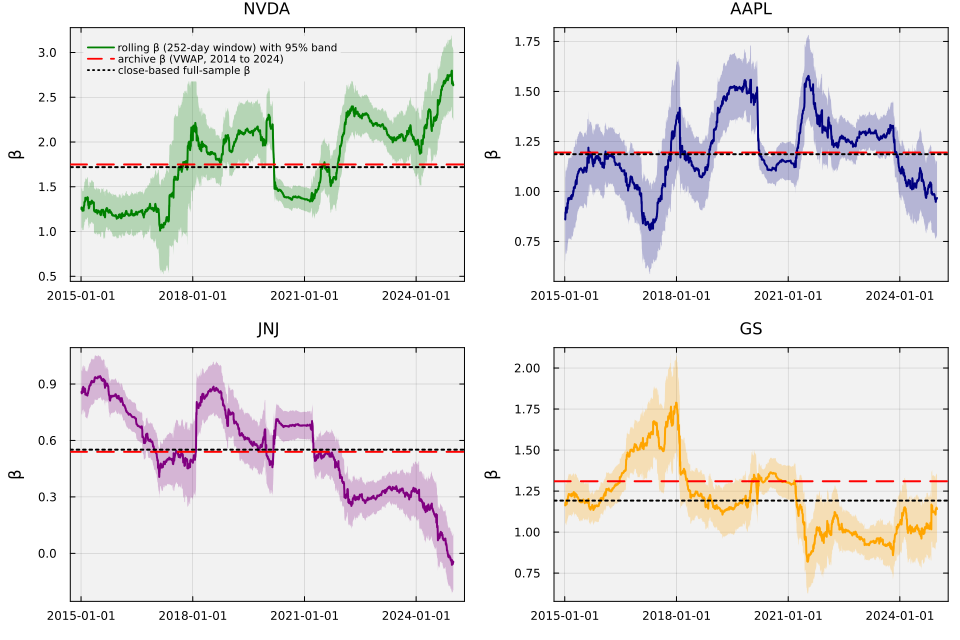

In [10]:
let
    plots = [];
    for (ticker, color) ∈ [("NVDA", :green), ("AAPL", :navy), ("JNJ", :purple), ("GS", :orange)]
        k = findfirst(==(ticker), my_list_of_tickers);
        v = rolling[ticker]; idx = window:size(v, 1);
        p = plot(dates_train[idx], v[idx, 1], ribbon = 1.96 .* v[idx, 2], fillalpha = 0.25, lw = 2, c = color, label = "rolling β ($(window)-day window) with 95% band");
        hline!(p, [β̂[k]], lw = 2, ls = :dash, c = :red, label = "archive β (VWAP, 2014 to 2024)");
        hline!(p, [β̂_close[k]], lw = 2, ls = :dot, c = :black, label = "close-based full-sample β");
        plot!(p, title = ticker, titlefontsize = 11, ylabel = "β", bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = (ticker == "NVDA" ? :topleft : false), legendfontsize = 7); # one legend, in the panel where it hides nothing
        push!(plots, p);
    end
    plot(plots..., layout = (2, 2), size = (960, 640), left_margin = 4Plots.mm, bottom_margin = 3Plots.mm)
end

NVDA's rolling beta runs from about 1.0 to 2.8 across the decade against a pooled value of 1.75, JNJ's falls from 0.9 toward zero and back, AAPL's moves about 0.4 from its full-sample value in either direction, GS's runs from 0.8 to 1.8 around a full-sample value of 1.2, and the excursions last for years, not days. Under the classical assumptions a constant beta would rarely produce that; under the real dependence of daily data the bands are too narrow and the exclusions are correlated, so this is a description, not a test. It motivates testing a predeclared updating rule; it does not establish that updating will improve the engine.
___

## Task 3: EWLS and the Walk-Forward Half-Life Choice
Exponentially weighted least squares (EWLS) replaces the flat OLS weights by weights that decay geometrically with age. With a decay factor $\delta = 2^{-1/t_{1/2}}\in(0,1)$ set by the __half-life__ $t_{1/2}$ in trading days, the estimate at time $t$ minimizes $\sum_{s\le t}\delta^{\,t-s}(g_{i,s} - \alpha_{i} - \beta_{i}g_{M,s})^{2}$, and it is computed by a recursion on three running moments: the weighted Gram matrix $\mathbf{A}_{t}$, the weighted cross-moment vector $\mathbf{b}_{t}$, and the weighted second moment $c_{t}$ of the response (lecture, and the derivation in the optional advanced notebook). The recursion is seeded with a __prior__ $(\alpha_{i,0}, \beta_{i,0}, \sigma_{\varepsilon,i,0})$ worth $N_{0}$ pseudo-observations, whose weight then decays like the data's, so that at any time the estimate is a weighted compromise between the prior and what has been seen since. The course package implements the seed [in the `ewls_init(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.ewls_init), the one-observation update [in the `ewls_update!(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.ewls_update!), and the whole path [in the `ewls_path(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.ewls_path), which returns a matrix whose row $t$ holds $(\hat{\alpha}_{i,t}, \hat{\beta}_{i,t}, \hat{\sigma}_{\varepsilon,i,t})$ after observation $t$.

The half-life is a choice, and it must be made before 2025 is opened. We choose it by a __walk-forward__ comparison inside the training period: for each candidate $t_{1/2}$ we run the recursion over the training growth rates, seeded with an OLS fit on the first `warmup_days` = 252 training growth rates alone (January 6, 2014 to January 5, 2015; the recursion never sees the archive's full-sample answer), and on every day $t$ from `first_evaluation_date` (January 2, 2020) to the end of 2024 we predict the firm's growth rate from the parameters estimated through $t-1$ and the market's growth on day $t$, $\hat{g}_{i,t\,|\,t-1} = \hat{\alpha}_{i,t-1} + \hat{\beta}_{i,t-1}\,g_{M,t}$, and score the squared error. This is a __conditional__ one-step-ahead evaluation: the parameters are lagged, the market's growth on day $t$ is not, so it tests how well yesterday's parameters describe today's co-movement, and it is not a tradable forecast. The score is the mean squared error over the evaluation days and the thirteen firms (units: inverse years squared). Because the residual variance dominates that number whatever the half-life, we also report each candidate relative to the recursion with no forgetting ($t_{1/2} = \infty$: with the warm-up seed its coefficients are those of the expanding-window OLS), which is the reference a frozen parameter would like to be, and we record which half-life wins for each firm. We store the table in the `walk_forward::DataFrame` variable and the winning half-life in the `half_life_star::Float64` variable:

In [11]:
walk_forward, half_life_star = let
    evaluation_days = findall(d -> d >= first_evaluation_date, dates_train);
    df = DataFrame(half_life = String[], MSE = Float64[], relative_to_no_forgetting = Float64[]);
    mse = Dict{Float64, Float64}(); mse_by_firm = Dict{Float64, Vector{Float64}}();
    for t_half ∈ half_lives
        errors = zeros(length(my_list_of_tickers));
        for (k, ticker) ∈ enumerate(my_list_of_tickers)
            estimates = ewls_path(g_M_train, G_train[:, k]; half_life = t_half, warmup = warmup_days); # prior: OLS on the first 252 growth rates; rows 1:warmup are NaN
            e = [G_train[t, k] - (estimates[t-1, 1] + estimates[t-1, 2]*g_M_train[t]) for t ∈ evaluation_days]; # conditional one-step-ahead: parameters through t−1, market growth on t
            errors[k] = mean(e.^2);
        end
        mse[t_half] = mean(errors); mse_by_firm[t_half] = errors;
    end
    winners = [half_lives[argmin([mse_by_firm[t_half][k] for t_half ∈ half_lives])] for k ∈ 1:length(my_list_of_tickers)]; # best half-life per firm
    for t_half ∈ half_lives
        push!(df, (half_life = isinf(t_half) ? "∞ (no forgetting)" : string(Int(t_half)), MSE = round(mse[t_half], digits=3), relative_to_no_forgetting = round(mse[t_half]/mse[Inf], digits=4)));
    end
    half_life_star = half_lives[argmin([mse[t_half] for t_half ∈ half_lives])];
    println("warm-up seed: OLS on growth rates $(dates_train[1]) to $(dates_train[warmup_days]); evaluation window: $(dates_train[evaluation_days[1]]) to $(dates_train[evaluation_days[end]]) ($(length(evaluation_days)) days, 13 firms); the winning half-life is t½⋆ = $(half_life_star) trading days, declared before 2025 is opened")
    println("best half-life per firm: ", join(["$(ticker) $(isinf(w) ? "∞" : Int(w))" for (ticker, w) ∈ zip(my_list_of_tickers, winners)], ", "))
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    (df, half_life_star); # return
end;

warm-up seed: OLS on growth rates 2014-01-06 to 2015-01-05; evaluation window: 2020-01-02 to 2024-12-31 (1258 days, 13 firms); the winning half-life is t½⋆ = 63.0 trading days, declared before 2025 is opened
best half-life per firm: AAPL ∞, MSFT ∞, INTC 63, MU 63, AMD 63, NVDA 63, GS 126, BAC 126, WFC 63, C 63, F 252, GM 252, JNJ 63
 ------------------- --------- ---------------------------
          half_life       MSE   relative_to_no_forgetting 
             String   Float64                     Float64 
 ------------------- --------- ---------------------------
                 21    22.846                       0.995
                 63    22.531                      0.9813
                126    22.582                      0.9835
                252    22.728                      0.9899
  ∞ (no forgetting)     22.96                         1.0
 ------------------- --------- ---------------------------


The differences are small in absolute terms, a few percent of a mean squared error that is mostly irreducible residual variance, and the aggregate ordering is clear: a one-quarter half-life describes the next day's co-movement best, a one-month half-life is too noisy, and no forgetting is worst. Firm by firm the picture is less tidy, and we print it rather than smooth it over: a finite memory wins for eleven of the thirteen firms (one quarter for seven, half a year for two, a year for two), and for AAPL and MSFT no forgetting wins. We __declare__ $t_{1/2}^{\star} = 63$ trading days on the aggregate here, and nothing below re-tunes it on 2025. One honest remark about the criterion: it scores the combined prediction $\hat{\alpha} + \hat{\beta}g_{M,t}$, so it neither isolates the quality of the intercept nor scores the threshold classification $\tilde{g}_{M,t} > -\alpha_{i}/\beta_{i}$ that the engine acts on. How the engine fares with a memory this short is what the replay is for.
___

## Task 4: The Online Paths Through 2025
Now we open 2025. The __online__ arm restarts the recursion on the first trading day of 2025 from the archive prior $(\hat{\alpha}_{i}, \hat{\beta}_{i}, s_{g,\varepsilon,i})$ with weight $N_{0} = 63$ pseudo-observations, seeded through the archive's training market moments ($\mathbf{A}_{0} = N_{0}\,\mathbb{E}[\mathbf{x}\mathbf{x}^{\top}]$ with $\mathbf{x} = (1, g_{M})^{\top}$), and updates one close-based growth rate at a time with the declared half-life. The __frozen__ arm is the archive. Timing follows L7a: the parameters used on 2025 day $t$ come from growth rates through day $t-1$, so on the first day of 2025 the online arm equals the frozen arm exactly, on the second day it has absorbed one 2025 observation (the growth into the first close of 2025 from the last close of 2024), and so on. We keep the parameters as they stood __before__ each day's observation, which is the shift the engine needs, and store the paths in the `α_online::Array{Float64,2}`, `β_online::Array{Float64,2}`, and `σ_ε_online::Array{Float64,2}` variables (rows are 2025 days, columns are firms), asserting the first-day identity:

In [12]:
α_online, β_online, σ_ε_online = let
    N = size(G_2025, 1); number_of_assets = length(my_list_of_tickers);
    α_online = zeros(N, number_of_assets); β_online = zeros(N, number_of_assets); σ_ε_online = zeros(N, number_of_assets);
    for k ∈ 1:number_of_assets
        state = ewls_init(α̂[k], β̂[k], sqrt(s²_ε[k]); half_life = half_life_star, prior_weight = N₀, market_mean = g_market_mean, market_variance = σ²_market); # archive prior worth N₀ pseudo-observations
        for t ∈ 1:N
            α_online[t, k], β_online[t, k], σ_ε_online[t, k] = state.α, state.β, state.σ_ε; # parameters used on day t: growth rates through day t−1
            ewls_update!(state, G_2025[t, k], g_M_2025[t]); # fold in the growth into the close of day t, available after that close
        end
    end
    @assert all(α_online[1, :] .== α̂) && all(β_online[1, :] .== β̂) && all(σ_ε_online[1, :] .== sqrt.(s²_ε)) # day 1: the prior, exactly
    (α_online, β_online, σ_ε_online); # return
end;
let
    df = DataFrame(ticker = String[], β_frozen = Float64[], β_online_min = Float64[], β_online_max = Float64[], β_online_end = Float64[], α_frozen = Float64[], α_online_min = Float64[], α_online_max = Float64[]);
    for (k, ticker) ∈ enumerate(my_list_of_tickers)
        push!(df, (ticker = ticker, β_frozen = round(β̂[k], digits=2), β_online_min = round(minimum(β_online[:, k]), digits=2), β_online_max = round(maximum(β_online[:, k]), digits=2), β_online_end = round(β_online[end, k], digits=2),
            α_frozen = round(α̂[k], digits=2), α_online_min = round(minimum(α_online[:, k]), digits=2), α_online_max = round(maximum(α_online[:, k]), digits=2)));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    nonpositive = [(my_list_of_tickers[k], count(β_online[:, k] .<= 0)) for k ∈ 1:length(my_list_of_tickers) if any(β_online[:, k] .<= 0)];
    println("firms whose online β was non-positive on some 2025 day (the L7a preference model then assigns the firm to the non-preferred set): $(nonpositive)")
end

 -------- ---------- -------------- -------------- -------------- ---------- -------------- --------------
  ticker   β_frozen   β_online_min   β_online_max   β_online_end   α_frozen   α_online_min   α_online_max 
  String    Float64        Float64        Float64        Float64    Float64        Float64        Float64 
 -------- ---------- -------------- -------------- -------------- ---------- -------------- --------------
    AAPL       1.19            0.9           1.36           1.11       0.11          -0.51           0.28
    MSFT       1.15           0.82           1.21           0.84        0.1          -0.21            0.4
    INTC       1.18            0.7            1.8           1.75      -0.15          -0.54           1.05
      MU        1.7           1.58           2.58           2.56      -0.05          -0.23           1.38
     AMD       1.74           1.64           2.31           2.29       0.13          -0.57           1.09
    NVDA       1.75           1.73        

`Unhide` the code block below to see the online intercept (left column) and beta (right column) through 2025 for the same four firms (solid lines), with the frozen archive values as dashed red lines; the legend in the first panel applies to all eight. The betas move by half a unit or more within the year, and the intercepts swing by several tenths per year around values that are themselves only a few tenths: with a one-quarter memory the intercept is the least identified parameter of the model, as it already was in L6a with eleven years of data.

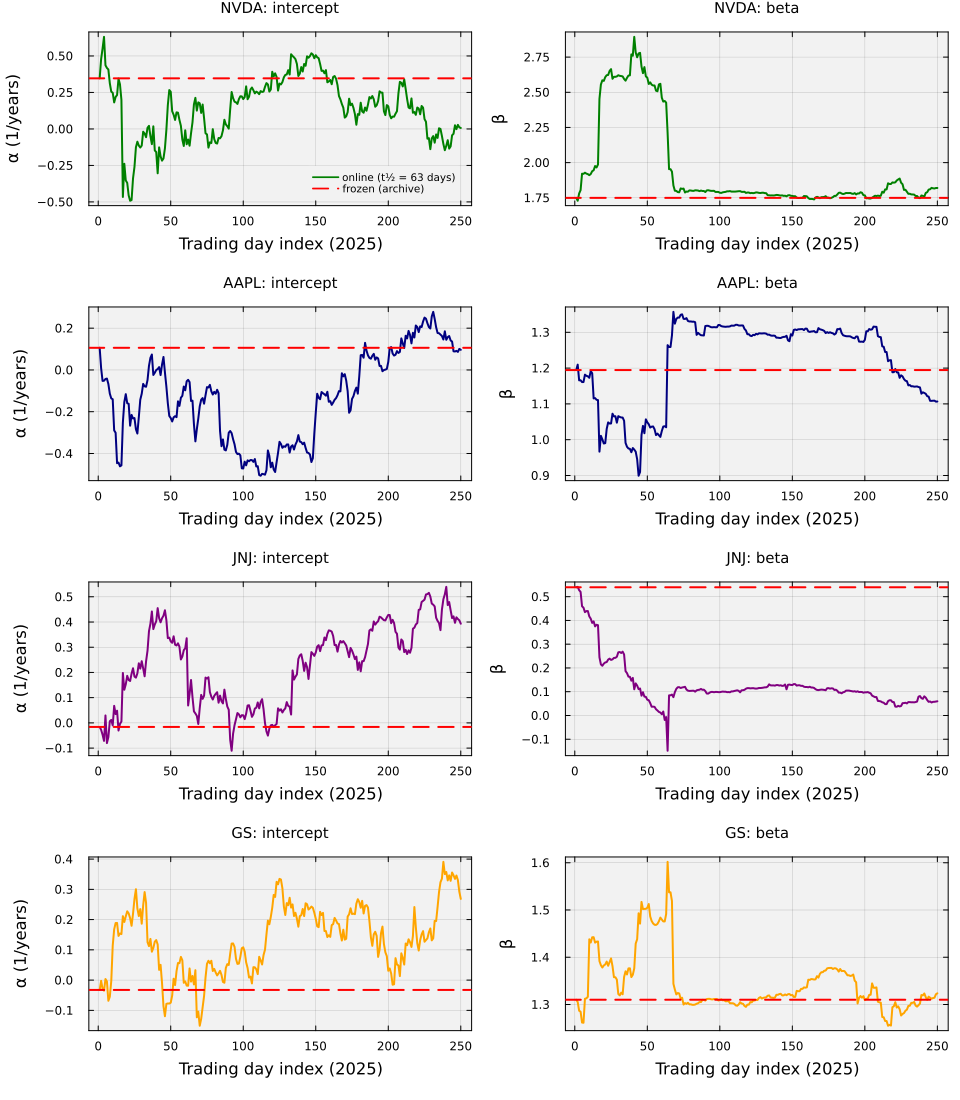

In [13]:
let
    N = size(α_online, 1); plots = [];
    for (ticker, color) ∈ [("NVDA", :green), ("AAPL", :navy), ("JNJ", :purple), ("GS", :orange)]
        k = findfirst(==(ticker), my_list_of_tickers);
        pα = plot(1:N, α_online[:, k], lw = 2, c = color, label = "online (t½ = $(Int(half_life_star)) days)");
        hline!(pα, [α̂[k]], lw = 2, ls = :dash, c = :red, label = "frozen (archive)");
        plot!(pα, title = "$(ticker): intercept", titlefontsize = 10, ylabel = "α (1/years)", bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = (ticker == "NVDA" ? :bottomright : false), legendfontsize = 7); # one legend for all panels, placed where it hides nothing
        pβ = plot(1:N, β_online[:, k], lw = 2, c = color, label = "");
        hline!(pβ, [β̂[k]], lw = 2, ls = :dash, c = :red, label = "");
        plot!(pβ, title = "$(ticker): beta", titlefontsize = 10, ylabel = "β", bg = "gray95", background_color_outside = "white", framestyle = :box, legend = false);
        push!(plots, pα); push!(plots, pβ);
    end
    plot(plots..., layout = (4, 2), size = (960, 1100), xlabel = "Trading day index (2025)", left_margin = 4Plots.mm, bottom_margin = 3Plots.mm)
end

Two remarks about the speed of the update. First, every residual receives its age weight, but the information a day carries about the slope scales with the square of its centered market growth (it is what the day adds to the slope direction of $\mathbf{A}_{t}$), and the prior's pseudo-observations carry the archive's VWAP-based market variance of 4.6 per year squared against 7.5 for close-based days: 63 archive pseudo-observations carry roughly the slope information of $63\times 4.6/7.5\approx 39$ average close-based days before any decay, and far fewer in a volatile month, so the prior lets go of the slope faster than the count of 63 suggests. Second, one episode deserves a sentence. In early April 2025 the market fell sharply while JNJ rose, and for three days the online beta of JNJ, with only a quarter of memory, went below zero. The L7a preference model raises beta to a real power, and its stated rule for a non-positive beta is assignment to the non-preferred set; the next task applies that rule. A frozen parameter cannot do this to you; a fast one can, and the rule has to be written down in advance. A related caveat: the rule guards $\beta\leq 0$ only, and a small positive beta makes the lens $\beta_{i}^{\xi_{t}}$ and the threshold $-\alpha_{i}/\beta_{i}$ numerically extreme (JNJ's online beta ends the year at 0.06); the sign rule stays continuous through zero, but the magnitude of $\gamma_{i}(t)$ saturates, which is the model behaving as written rather than a bug, and a positive floor on beta would be the engineering fix.
___

## Task 5: What the Update Changes: Thresholds, the Basket, and the SIM Covariance
The L7a preference model classifies firm $i$ as preferred on day $t$ when the recent market growth exceeds its threshold, $\tilde{g}_{M,t} > -\alpha_{i}/\beta_{i}$, and the signal $\xi_{t}$ moves the magnitudes: $\gamma_{i}(t) = \tanh(\alpha_{i}/\beta_{i}^{\xi_{t}} + \beta_{i}^{1-\xi_{t}}\tilde{g}_{M,t})$. With frozen parameters the thresholds are fixed and only $\tilde{g}_{M,t}$ moves; with online parameters the thresholds move too. We rebuild the two lagged market inputs for 2025 exactly as the L7a engine example did (the EMAs on the joined SPY close series, the gain calibrated on the training portion, both shifted one day) and compute the preference weights under both arms, applying the non-positive-beta rule ($\gamma_{i}(t) = 0$, non-preferred) where the online beta requires it. We store the inputs in `ξ_lag::Array{Float64,1}` and `g̃_M_lag::Array{Float64,1}` and the preference weights in `Γ_frozen::Array{Float64,2}` and `Γ_online::Array{Float64,2}` (rows are 2025 days, columns are firms), and tabulate, firm by firm, the frozen threshold, the online threshold at the end of the year, the number of 2025 days each arm preferred the firm, and the number of days the two arms disagreed:

In [14]:
ξ_lag, g̃_M_lag, Γ_frozen, Γ_online = let
    spy_train = dataset["SPY"][:, :close]; spy_2025 = dataset_2025["SPY"][:, :close];
    N_train = length(spy_train); N = length(spy_2025);

    # gain from the training portion only, inputs on the joined series shifted one day (as in the L7a engine example) -
    S̄_short_train = compute_ema(spy_train, L_short); S̄_long_train = compute_ema(spy_train, L_long);
    t₀ = L_short + L_long;
    G = 1.0/quantile(abs.(S̄_short_train[t₀:end] ./ S̄_long_train[t₀:end] .- 1.0), 0.99);
    spy_all = vcat(spy_train, spy_2025);
    S̄_short = compute_ema(spy_all, L_short); S̄_long = compute_ema(spy_all, L_long);
    ξ_all = -G .* (S̄_short ./ S̄_long .- 1.0);
    g_M_all = log.(spy_all[2:end] ./ spy_all[1:end-1]) ./ Δt; g̃_all = compute_ema(g_M_all, L_growth);
    ξ_lag = [ξ_all[N_train + t - 1] for t ∈ 1:N]; g̃_M_lag = [g̃_all[N_train + t - 2] for t ∈ 1:N]; # 2025 day t uses prices through day t−1

    # preference weights under both arms, with the non-positive-beta rule -
    preference(α, β, ξ, g̃) = [β[i] > 0 ? tanh(α[i]/β[i]^ξ + β[i]^(1 - ξ)*g̃) : 0.0 for i ∈ eachindex(α)];
    Γ_frozen = hcat([preference(α̂, β̂, ξ_lag[t], g̃_M_lag[t]) for t ∈ 1:N]...)' |> Matrix;
    Γ_online = hcat([preference(α_online[t, :], β_online[t, :], ξ_lag[t], g̃_M_lag[t]) for t ∈ 1:N]...)' |> Matrix;
    (ξ_lag, g̃_M_lag, Γ_frozen, Γ_online); # return
end;
let
    N = size(Γ_frozen, 1);
    df = DataFrame(ticker = String[], threshold_frozen = Float64[], threshold_online_end = Float64[], days_preferred_frozen = Int[], days_preferred_online = Int[], days_disagree = Int[]);
    for (k, ticker) ∈ enumerate(my_list_of_tickers)
        push!(df, (ticker = ticker, threshold_frozen = round(-α̂[k]/β̂[k], digits=3), threshold_online_end = round(-α_online[end, k]/β_online[end, k], digits=3),
            days_preferred_frozen = count(Γ_frozen[:, k] .> 0), days_preferred_online = count(Γ_online[:, k] .> 0), days_disagree = count((Γ_frozen[:, k] .> 0) .!= (Γ_online[:, k] .> 0))));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("days with an empty basket: frozen $(count([all(Γ_frozen[t, :] .<= 0) for t ∈ 1:N])), online $(count([all(Γ_online[t, :] .<= 0) for t ∈ 1:N])); days with all 13 firms preferred: frozen $(count([all(Γ_frozen[t, :] .> 0) for t ∈ 1:N])), online $(count([all(Γ_online[t, :] .> 0) for t ∈ 1:N]))")
end

 -------- ------------------ ---------------------- ----------------------- ----------------------- ---------------
  ticker   threshold_frozen   threshold_online_end   days_preferred_frozen   days_preferred_online   days_disagree 
  String            Float64                Float64                   Int64                   Int64           Int64 
 -------- ------------------ ---------------------- ----------------------- ----------------------- ---------------
    AAPL             -0.089                 -0.087                     183                     153              32
    MSFT             -0.087                  0.142                     183                     177              14
    INTC              0.125                 -0.205                     152                     179              35
      MU              0.031                 -0.488                     166                     196              32
     AMD             -0.073                 -0.082                     181  

The frozen thresholds sit within a few tenths per year of zero, so the basket is decided by whether the recent market growth is above or below a narrow band; the online intercepts move the thresholds by more than that band's width, so the two arms disagree on the classification of a typical firm on a few dozen days of the year, and the online arm rarely empties the basket. Whether that helps is a question for the engine (the next example), not for this table.

The update also moves the second input of L6b, the SIM covariance matrix $\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}$, through the betas and the residual variances. What follows is a __parameter-only sensitivity__: we hold the market variance $s^{2}_{g,M}$ at its training value and swap in the online betas and residual scales, so the matrix is neither the archive's nor a fully re-estimated close-based one, and the distance isolates what the parameter update alone does to it. We measure the distance between the online and frozen matrices by the Frobenius norm of their difference, $\lVert\hat{\mathbf{\Sigma}}^{\text{online}}_{t} - \hat{\mathbf{\Sigma}}^{\text{frozen}}\rVert_{F} = \left(\sum_{i,j}(\Sigma^{\text{online}}_{ij,t} - \Sigma^{\text{frozen}}_{ij})^{2}\right)^{1/2}$, relative to $\lVert\hat{\mathbf{\Sigma}}^{\text{frozen}}\rVert_{F}$, on the first day of each 21-day block of 2025 (the L7a engine's monthly rebalance days). We store the table in the `covariance_distance::DataFrame` variable:

In [15]:
covariance_distance = let
    Σ_frozen = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)
    df = DataFrame(day = Int[], frobenius_distance = Float64[], relative = Float64[]);
    for t ∈ 1:21:size(β_online, 1)
        Σ_t = σ²_market .* (β_online[t, :] * β_online[t, :]') .+ Diagonal(σ_ε_online[t, :].^2) |> Matrix;
        push!(df, (day = t, frobenius_distance = round(norm(Σ_t - Σ_frozen), digits=2), relative = round(norm(Σ_t - Σ_frozen)/norm(Σ_frozen), digits=3)));
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    df; # return
end;

 ------- -------------------- ----------
    day   frobenius_distance   relative 
  Int64              Float64    Float64 
 ------- -------------------- ----------
      1                  0.0        0.0
     22                59.53      0.402
     43                78.95      0.533
     64                84.19      0.569
     85                74.64      0.504
    106                63.24      0.427
    127                59.39      0.401
    148                58.19      0.393
    169                61.06      0.412
    190                87.72      0.593
    211                83.57      0.564
    232                93.11      0.629
 ------- -------------------- ----------


After the identical first day, the online covariance matrix is 39% to 63% away from the frozen one in Frobenius norm on every displayed rebalance day of the year: a minimum-variance allocation built from the online inputs could differ materially from the frozen one (how much the weights would move is a computation we do not make here). The L7a engine does not use the covariance matrix, but the L6b allocations do, and this is the size of the input change that a one-quarter memory produces.
___

## Summary
In this example, we showed that the frozen archive betas were not stable inside the training period, ran the EWLS recursion on close-based growth rates, chose and declared its half-life by a walk-forward comparison of conditional one-step-ahead prediction errors inside 2014 to 2024, replayed the recursion through 2025 from the archive prior, and measured what the update did to the intercepts, betas, preference thresholds, basket, and SIM covariance matrix.

> __Key Takeaways:__
>
> * __Rolling bands give the motion a scale, not a verdict:__ A rolling one-year beta with its classical pointwise band shows NVDA, AAPL, JNJ, and GS spending years several band-widths away from their pooled full-sample values, which motivates testing a predeclared updating rule; the bands assume independence the data lack and the windows overlap, so this describes instability rather than proving it.
> * __The half-life is a declared aggregate choice:__ The walk-forward comparison of conditional one-step-ahead errors on 2020 to 2024, seeded on the first year of training growth rates, ranks a one-quarter half-life first on aggregate and for seven of the thirteen firms, a one-month half-life as too noisy, and no forgetting last, but the criterion scores the combined prediction and not the threshold classification the engine acts on.
> * __A short memory moves the intercept most:__ Restarted from the archive prior on 2025, the online betas moved by half a unit or more and the intercepts by several tenths per year, the thresholds and the basket classification changed on a few dozen days per firm, one beta briefly went non-positive and was handled by the stated rule, and the parameter-only SIM covariance matrix moved 39% to 63% away from the frozen one after the first day.

Next, in the scenario-ensemble example, we put the frozen and online parameters into the L7a engine on the realized 2025 path and on an ensemble of simulated futures, and read the distributional scorecard.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___